# FASE 1 - Paso 2-7: Fine-tuning Clasificación TASS

**Objetivo**: Fine-tuning de modelos transformer para clasificación de sentimientos en TASS.

**Modelos a entrenar**:
- XLNet (xlnet-base-cased)
- XLM-RoBERTa (xlm-roberta-base)

**Dataset**: TASS (Twitter Analysis for Spanish Sentiment)
- **Clases**: N (Negativo), NEU (Neutral), P (Positivo)
- **Train**: 3,841 muestras
- **Validation**: 961 muestras
- **Test**: 2,443 muestras

**⚠️ IMPORTANTE - CONFIGURACIÓN GPU**: 
- Este notebook requiere **GPU en Kaggle**
- **GPU Recomendada**: GPU T4 o GPU P100
- **Si ves warnings de CUDA**: Usa GPU T4 (Settings → Accelerator → GPU T4)
- Tiempo estimado: 30-45 min por modelo

---

## 📋 Checklist de Ejecución en Kaggle

Antes de ejecutar:
- [ ] Subir archivos CSV a Kaggle Input
- [ ] ⚠️ **Configurar GPU T4** en Settings (no P100 si hay incompatibilidad)
- [ ] Tener token de HuggingFace con permisos de escritura
- [ ] Verificar 30h de GPU disponibles

---

## 1. Configuración del Entorno

In [2]:
# Verificar GPU disponible
import torch
import sys

print("="*70)
print("🔧 VERIFICACIÓN DE ENTORNO")
print("="*70)

print(f"\n🐍 Python: {sys.version}")
print(f"🔥 PyTorch: {torch.__version__}")
print(f"🎮 CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"   GPU: {gpu_name}")
    print(f"   Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Verificar compatibilidad CUDA
    cuda_capability = torch.cuda.get_device_capability(0)
    print(f"   CUDA Capability: {cuda_capability[0]}.{cuda_capability[1]}")
    
    # Advertencia si es P100 con PyTorch incompatible
    if cuda_capability[0] < 7:
        print(f"\n   ⚠️  WARNING: GPU P100 detectada con PyTorch incompatible")
        print(f"   ⚠️  PyTorch actual solo soporta CUDA capability >= 7.0")
        print(f"   ⚠️  Tu GPU tiene capability {cuda_capability[0]}.{cuda_capability[1]}")
        print(f"\n   🔧 SOLUCIÓN:")
        print(f"   1. Ve a Settings → Accelerator")
        print(f"   2. Cambia de 'GPU P100' a 'GPU T4'")
        print(f"   3. Guarda y re-ejecuta este notebook desde el inicio")
        print(f"\n   💡 GPU T4 es más rápida y compatible con esta versión de PyTorch")
        print("="*70)
        raise RuntimeError("GPU incompatible. Por favor usa GPU T4 en lugar de P100.")
    
    device = torch.device("cuda")
    print(f"   ✅ GPU compatible - Usando GPU")
else:
    device = torch.device("cpu")
    print(f"   ⚠️ GPU no disponible - Usando CPU (será MUY lento)")
    print(f"   🔧 SOLUCIÓN: Activa GPU en Settings → Accelerator → GPU T4")

print("="*70)

🔧 VERIFICACIÓN DE ENTORNO

🐍 Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
🔥 PyTorch: 2.10.0+cu128
🎮 CUDA disponible: True
   GPU: Tesla T4
   Memoria GPU: 15.64 GB
   CUDA Capability: 7.5
   ✅ GPU compatible - Usando GPU


## 2. Instalar/Importar Librerías

In [3]:
# Instalar librerías necesarias (solo si no están instaladas)
import subprocess
import sys

def install_if_needed(package):
    try:
        __import__(package)
        print(f"✅ {package} ya instalado")
    except ImportError:
        print(f"📦 Instalando {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {package} instalado")

print("🔍 Verificando dependencias...\n")

packages = [
    'transformers',
    'datasets',
    'evaluate',
    'scikit-learn',
    'accelerate',
    'huggingface_hub'
]

for pkg in packages:
    install_if_needed(pkg)

print("\n✅ Todas las dependencias están listas")

🔍 Verificando dependencias...

✅ transformers ya instalado
✅ datasets ya instalado
📦 Instalando evaluate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00
✅ evaluate instalado
📦 Instalando scikit-learn...
✅ scikit-learn instalado
✅ accelerate ya instalado
✅ huggingface_hub ya instalado

✅ Todas las dependencias están listas


In [4]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
import evaluate

# HuggingFace Hub
from huggingface_hub import login, HfApi

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 3. Configuración de HuggingFace Hub

⚠️ **INSTRUCCIÓN**: Ingresa tu token de HuggingFace cuando se solicite.

El token debe tener permisos de **escritura** para poder publicar modelos.

In [5]:
# Configurar token de HuggingFace
from getpass import getpass

print("🔑 Configuración de HuggingFace Hub")
print("="*70)
print("📌 Tu token debe tener permisos de ESCRITURA")
print("📌 Obtén tu token en: https://huggingface.co/settings/tokens")
print("="*70)

try:
    # Intentar leer token desde archivo (si existe localmente)
    with open('/kaggle/input/hf-token/hf_token.txt', 'r') as f:
        hf_token = f.read().strip()
    print("✅ Token leído desde archivo")
except FileNotFoundError:
    # Si no existe, solicitar manualmente
    hf_token = getpass("\n🔐 Ingresa tu token de HuggingFace: ")

# Autenticarse
try:
    login(token=hf_token)
    api = HfApi()
    user_info = api.whoami()
    username = user_info['name']
    print(f"\n✅ Autenticado como: {username}")
    print("="*70)
except Exception as e:
    print(f"\n❌ Error en autenticación: {e}")
    print("⚠️ Verifica tu token y vuelve a intentar")
    raise

🔑 Configuración de HuggingFace Hub
📌 Tu token debe tener permisos de ESCRITURA
📌 Obtén tu token en: https://huggingface.co/settings/tokens



🔐 Ingresa tu token de HuggingFace:  ········



✅ Autenticado como: Lucyan85


## 4. Cargar Datasets Procesados

Los datasets fueron procesados en el notebook anterior (`1_Exploracion_TASS.ipynb`).

**Ubicación esperada**:
- `/kaggle/input/tass-processed/tass_train.csv`
- `/kaggle/input/tass-processed/tass_validation.csv`
- `/kaggle/input/tass-processed/tass_test.csv`

⚠️ **INSTRUCCIÓN**: Antes de ejecutar este notebook en Kaggle:
1. Crea un nuevo dataset en Kaggle llamado "tass-processed"
2. Sube los 3 archivos CSV desde `resultados/fase1_tass/`
3. Adjunta el dataset a este notebook

In [6]:
# Cargar datasets
print("📂 Cargando datasets procesados...")
print("="*70)

# Rutas (ajustar según ubicación en Kaggle)
TRAIN_PATH = '/kaggle/input/datasets/julianquimbayocastro/tass-processed/tass_train.csv'
VAL_PATH = '/kaggle/input/datasets/julianquimbayocastro/tass-processed/tass_validation.csv'
TEST_PATH = '/kaggle/input/datasets/julianquimbayocastro/tass-processed/tass_test.csv'

try:
    df_train = pd.read_csv(TRAIN_PATH)
    df_val = pd.read_csv(VAL_PATH)
    df_test = pd.read_csv(TEST_PATH)
    
    print(f"✅ Train: {len(df_train)} muestras")
    print(f"✅ Validation: {len(df_val)} muestras")
    print(f"✅ Test: {len(df_test)} muestras")
    print(f"\n📊 Total: {len(df_train) + len(df_val) + len(df_test)} muestras")
    
except FileNotFoundError as e:
    print(f"\n❌ Error: No se encontraron los archivos CSV")
    print(f"\n⚠️ ACCIÓN REQUERIDA:")
    print(f"   1. Descarga los CSV desde: resultados/fase1_tass/")
    print(f"   2. Crea un dataset en Kaggle llamado 'tass-processed'")
    print(f"   3. Sube los 3 archivos CSV")
    print(f"   4. Adjunta el dataset a este notebook")
    raise

# Verificar columnas
print(f"\n📋 Columnas detectadas: {df_train.columns.tolist()}")
TEXT_COL = 'sentencia original'
LABEL_COL = 'label'

print(f"\n🔍 Columna de texto: '{TEXT_COL}'")
print(f"🔍 Columna de etiqueta: '{LABEL_COL}'")

# Verificar clases
classes = sorted(df_train[LABEL_COL].unique())
print(f"\n🏷️ Clases encontradas: {classes}")
print("="*70)

📂 Cargando datasets procesados...
✅ Train: 3841 muestras
✅ Validation: 961 muestras
✅ Test: 2443 muestras

📊 Total: 7245 muestras

📋 Columnas detectadas: ['id', 'sentencia original', 'label', 'len_chars', 'len_words']

🔍 Columna de texto: 'sentencia original'
🔍 Columna de etiqueta: 'label'

🏷️ Clases encontradas: ['N', 'NEU', 'P']


## 5. Mapeo de Etiquetas a IDs

Convertir etiquetas de texto (N, NEU, P) a IDs numéricos (0, 1, 2).

In [7]:
# Crear mapeo de etiquetas
label_list = sorted(df_train[LABEL_COL].unique())
label2id = {label: idx for idx, label in enumerate(label_list)}
id2label = {idx: label for idx, label in enumerate(label_list)}

print("🔄 Mapeo de etiquetas:")
print("="*70)
for label, idx in label2id.items():
    count = len(df_train[df_train[LABEL_COL] == label])
    print(f"   {label:>6} → ID {idx}  ({count} muestras)")
print("="*70)

# Aplicar mapeo a los dataframes
df_train['label_id'] = df_train[LABEL_COL].map(label2id)
df_val['label_id'] = df_val[LABEL_COL].map(label2id)
df_test['label_id'] = df_test[LABEL_COL].map(label2id)

print(f"\n✅ Mapeo aplicado correctamente")
print(f"   - Número de clases: {len(label2id)}")

🔄 Mapeo de etiquetas:
        N → ID 0  (1508 muestras)
      NEU → ID 1  (1218 muestras)
        P → ID 2  (1115 muestras)

✅ Mapeo aplicado correctamente
   - Número de clases: 3


## 6. Convertir a Datasets de HuggingFace

In [8]:
# Crear datasets de HuggingFace
print("🔄 Convirtiendo a formato HuggingFace Dataset...")

# Seleccionar solo columnas necesarias
df_train_clean = df_train[[TEXT_COL, 'label_id']].rename(columns={TEXT_COL: 'text', 'label_id': 'label'})
df_val_clean = df_val[[TEXT_COL, 'label_id']].rename(columns={TEXT_COL: 'text', 'label_id': 'label'})
df_test_clean = df_test[[TEXT_COL, 'label_id']].rename(columns={TEXT_COL: 'text', 'label_id': 'label'})

# Crear datasets
train_dataset = Dataset.from_pandas(df_train_clean, preserve_index=False)
val_dataset = Dataset.from_pandas(df_val_clean, preserve_index=False)
test_dataset = Dataset.from_pandas(df_test_clean, preserve_index=False)

# Agrupar en DatasetDict
dataset_dict = DatasetDict({
    'train': train_dataset,
    'validation': val_dataset,
    'test': test_dataset
})

print("\n✅ Datasets creados:")
print(dataset_dict)

🔄 Convirtiendo a formato HuggingFace Dataset...

✅ Datasets creados:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 3841
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 961
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2443
    })
})


## 7. Función de Entrenamiento Unificada

Esta función entrena cualquier modelo con los hiperparámetros especificados.

In [9]:
def train_and_evaluate_model(
    model_name,
    dataset_dict,
    label2id,
    id2label,
    output_dir,
    batch_size=16,
    learning_rate=2e-5,
    num_epochs=5,
    max_length=128,
    save_to_hub=True,
    hub_model_id=None
):
    """
    Entrena y evalúa un modelo de clasificación.
    
    Args:
        model_name: Nombre del modelo preentrenado (e.g., 'xlnet-base-cased')
        dataset_dict: DatasetDict con train/validation/test
        label2id: Diccionario de etiquetas a IDs
        id2label: Diccionario de IDs a etiquetas
        output_dir: Directorio para guardar checkpoints
        batch_size: Tamaño de batch
        learning_rate: Tasa de aprendizaje
        num_epochs: Número de épocas
        max_length: Longitud máxima de tokens
        save_to_hub: Si guardar en HuggingFace Hub
        hub_model_id: ID del modelo en HuggingFace Hub
    
    Returns:
        trainer: Objeto Trainer entrenado
        results: Diccionario con métricas finales
    """
    
    print("\n" + "="*70)
    print(f"🚀 INICIANDO ENTRENAMIENTO: {model_name}")
    print("="*70)
    
    # 1. Cargar tokenizer
    print(f"\n📝 Cargando tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    # 2. Tokenizar datasets
    print(f"🔄 Tokenizando datasets (max_length={max_length})...")
    
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            padding='max_length',
            truncation=True,
            max_length=max_length
        )
    
    tokenized_datasets = dataset_dict.map(
        tokenize_function,
        batched=True,
        remove_columns=['text']
    )
    
    print(f"✅ Tokenización completada")
    
    # 3. Cargar modelo
    print(f"\n🤖 Cargando modelo {model_name}...")
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )
    
    # 4. Data collator
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    
    # 5. Métricas
    accuracy_metric = evaluate.load("accuracy")
    f1_metric = evaluate.load("f1")
    
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        
        acc = accuracy_metric.compute(predictions=predictions, references=labels)
        f1 = f1_metric.compute(predictions=predictions, references=labels, average='weighted')
        
        return {
            'accuracy': acc['accuracy'],
            'f1': f1['f1']
        }
    
    # 6. Training arguments
    print(f"\n⚙️ Configurando argumentos de entrenamiento...")
    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        push_to_hub=save_to_hub,
        hub_model_id=hub_model_id,
        hub_strategy="end",
        logging_steps=50,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),  # Mixed precision si hay GPU
        report_to="none"  # Desactivar W&B
    )
    
    print(f"   Batch size: {batch_size}")
    print(f"   Learning rate: {learning_rate}")
    print(f"   Épocas: {num_epochs}")
    print(f"   FP16: {training_args.fp16}")
    
    # 7. Trainer (sin parámetro tokenizer - ya no necesario en versión actual)
    print(f"\n🏋️ Creando Trainer...")
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets['train'],
        eval_dataset=tokenized_datasets['validation'],
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )
    
    # 8. Entrenar
    print(f"\n🔥 INICIANDO ENTRENAMIENTO...")
    print("="*70)
    train_result = trainer.train()
    
    print("\n✅ ENTRENAMIENTO COMPLETADO")
    print("="*70)
    
    # 9. Evaluar en validation
    print(f"\n📊 Evaluando en VALIDATION...")
    val_metrics = trainer.evaluate(tokenized_datasets['validation'])
    print(f"\n✅ Validation Accuracy: {val_metrics['eval_accuracy']:.4f}")
    print(f"✅ Validation F1: {val_metrics['eval_f1']:.4f}")
    
    # 10. Evaluar en test
    print(f"\n📊 Evaluando en TEST...")
    test_predictions = trainer.predict(tokenized_datasets['test'])
    test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
    test_true_labels = test_predictions.label_ids
    
    test_acc = accuracy_metric.compute(predictions=test_pred_labels, references=test_true_labels)
    test_f1 = f1_metric.compute(predictions=test_pred_labels, references=test_true_labels, average='weighted')
    
    print(f"\n✅ Test Accuracy: {test_acc['accuracy']:.4f}")
    print(f"✅ Test F1: {test_f1['f1']:.4f}")
    
    # 11. Guardar métricas
    results = {
        'model_name': model_name,
        'val_accuracy': val_metrics['eval_accuracy'],
        'val_f1': val_metrics['eval_f1'],
        'test_accuracy': test_acc['accuracy'],
        'test_f1': test_f1['f1'],
        'train_samples': len(tokenized_datasets['train']),
        'val_samples': len(tokenized_datasets['validation']),
        'test_samples': len(tokenized_datasets['test']),
        'batch_size': batch_size,
        'learning_rate': learning_rate,
        'epochs': num_epochs,
        'predictions': test_pred_labels,
        'true_labels': test_true_labels
    }
    
    # 12. Guardar modelo localmente
    print(f"\n💾 Guardando modelo en {output_dir}...")
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)
    
    print("\n" + "="*70)
    print(f"✅ MODELO {model_name} COMPLETADO")
    print("="*70)
    
    return trainer, results

## 8. Entrenar Modelo 1: BETO

**Modelo**: `dccuchile/bert-base-spanish-wwm-cased`
- Arquitectura: BERT (Bidirectional Encoder Representations from Transformers)
- Parámetros: ~110M
- Multilingüe: No (español específico)
- Contexto: Bidireccional
- **Ventaja**: Entrenado específicamente en corpus en español

In [10]:
# Configuración para BETO (español)
MODEL_1_NAME = "dccuchile/bert-base-spanish-wwm-cased"
MODEL_1_OUTPUT = "./beto-tass"
MODEL_1_HUB_ID = f"{username}/beto-tass-sentiment"

print(f"🎯 Modelo: {MODEL_1_NAME}")
print(f"📁 Output: {MODEL_1_OUTPUT}")
print(f"🌐 HuggingFace: {MODEL_1_HUB_ID}")

# Entrenar
trainer_beto, results_beto = train_and_evaluate_model(
    model_name=MODEL_1_NAME,
    dataset_dict=dataset_dict,
    label2id=label2id,
    id2label=id2label,
    output_dir=MODEL_1_OUTPUT,
    batch_size=16,  # Ajustar según memoria GPU
    learning_rate=2e-5,
    num_epochs=5,
    max_length=128,
    save_to_hub=True,
    hub_model_id=MODEL_1_HUB_ID
)

print("\n🎉 BETO entrenado exitosamente!")

🎯 Modelo: dccuchile/bert-base-spanish-wwm-cased
📁 Output: ./beto-tass
🌐 HuggingFace: Lucyan85/beto-tass-sentiment

🚀 INICIANDO ENTRENAMIENTO: dccuchile/bert-base-spanish-wwm-cased

📝 Cargando tokenizer...


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


✅ MODELO dccuchile/bert-base-spanish-wwm-cased COMPLETADO

🎉 BETO entrenado exitosamente!


## 9. Entrenar Modelo 2: XLM-RoBERTa

**Modelo**: `xlm-roberta-base`
- Arquitectura: RoBERTa (Robustly Optimized BERT)
- Parámetros: ~125M
- Multilingüe: Sí (100 idiomas)
- Contexto: Bidireccional

In [11]:
# Configuración para XLM-RoBERTa
MODEL_2_NAME = "xlm-roberta-base"
MODEL_2_OUTPUT = "./xlmr-tass"
MODEL_2_HUB_ID = f"{username}/xlmr-tass-sentiment"

print(f"🎯 Modelo: {MODEL_2_NAME}")
print(f"📁 Output: {MODEL_2_OUTPUT}")
print(f"🌐 HuggingFace: {MODEL_2_HUB_ID}")

# Entrenar
trainer_xlmr, results_xlmr = train_and_evaluate_model(
    model_name=MODEL_2_NAME,
    dataset_dict=dataset_dict,
    label2id=label2id,
    id2label=id2label,
    output_dir=MODEL_2_OUTPUT,
    batch_size=16,  # Ajustar según memoria GPU
    learning_rate=2e-5,
    num_epochs=5,
    max_length=128,
    save_to_hub=True,
    hub_model_id=MODEL_2_HUB_ID
)

print("\n🎉 XLM-RoBERTa entrenado exitosamente!")

🎯 Modelo: xlm-roberta-base
📁 Output: ./xlmr-tass
🌐 HuggingFace: Lucyan85/xlmr-tass-sentiment

🚀 INICIANDO ENTRENAMIENTO: xlm-roberta-base

📝 Cargando tokenizer...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            


✅ MODELO xlm-roberta-base COMPLETADO

🎉 XLM-RoBERTa entrenado exitosamente!


## 10. Comparación de Resultados

In [12]:
# Crear tabla comparativa
print("\n" + "="*80)
print("📊 RESUMEN DE RESULTADOS - CLASIFICACIÓN TASS")
print("="*80)

comparison_df = pd.DataFrame([
    {
        'Modelo': results_beto['model_name'],
        'Val Accuracy': f"{results_beto['val_accuracy']:.4f}",
        'Val F1': f"{results_beto['val_f1']:.4f}",
        'Test Accuracy': f"{results_beto['test_accuracy']:.4f}",
        'Test F1': f"{results_beto['test_f1']:.4f}",
        'Batch Size': results_beto['batch_size'],
        'LR': results_beto['learning_rate'],
        'Epochs': results_beto['epochs']
    },
    {
        'Modelo': results_xlmr['model_name'],
        'Val Accuracy': f"{results_xlmr['val_accuracy']:.4f}",
        'Val F1': f"{results_xlmr['val_f1']:.4f}",
        'Test Accuracy': f"{results_xlmr['test_accuracy']:.4f}",
        'Test F1': f"{results_xlmr['test_f1']:.4f}",
        'Batch Size': results_xlmr['batch_size'],
        'LR': results_xlmr['learning_rate'],
        'Epochs': results_xlmr['epochs']
    }
])

print("\n")
print(comparison_df.to_string(index=False))
print("\n" + "="*80)

# Determinar mejor modelo
best_model = 'BETO' if results_beto['test_f1'] > results_xlmr['test_f1'] else 'XLM-RoBERTa'
best_f1 = max(results_beto['test_f1'], results_xlmr['test_f1'])

print(f"\n🏆 MEJOR MODELO: {best_model}")
print(f"📈 F1-Score en Test: {best_f1:.4f}")

# Comparar con baseline
BASELINE_F1 = 0.64  # BETO baseline del curso
improvement = (best_f1 - BASELINE_F1) * 100

if best_f1 > BASELINE_F1:
    print(f"✅ MEJORA sobre baseline BETO: +{improvement:.2f} puntos porcentuales")
else:
    print(f"⚠️ Rendimiento inferior al baseline BETO: {improvement:.2f} puntos porcentuales")

print("="*80)


📊 RESUMEN DE RESULTADOS - CLASIFICACIÓN TASS


                               Modelo Val Accuracy Val F1 Test Accuracy Test F1  Batch Size      LR  Epochs
dccuchile/bert-base-spanish-wwm-cased       0.6649 0.6593        0.6533  0.6454          16 0.00002       5
                     xlm-roberta-base       0.6701 0.6679        0.6488  0.6441          16 0.00002       5


🏆 MEJOR MODELO: BETO
📈 F1-Score en Test: 0.6454
✅ MEJORA sobre baseline BETO: +0.54 puntos porcentuales


## 11. Matriz de Confusión

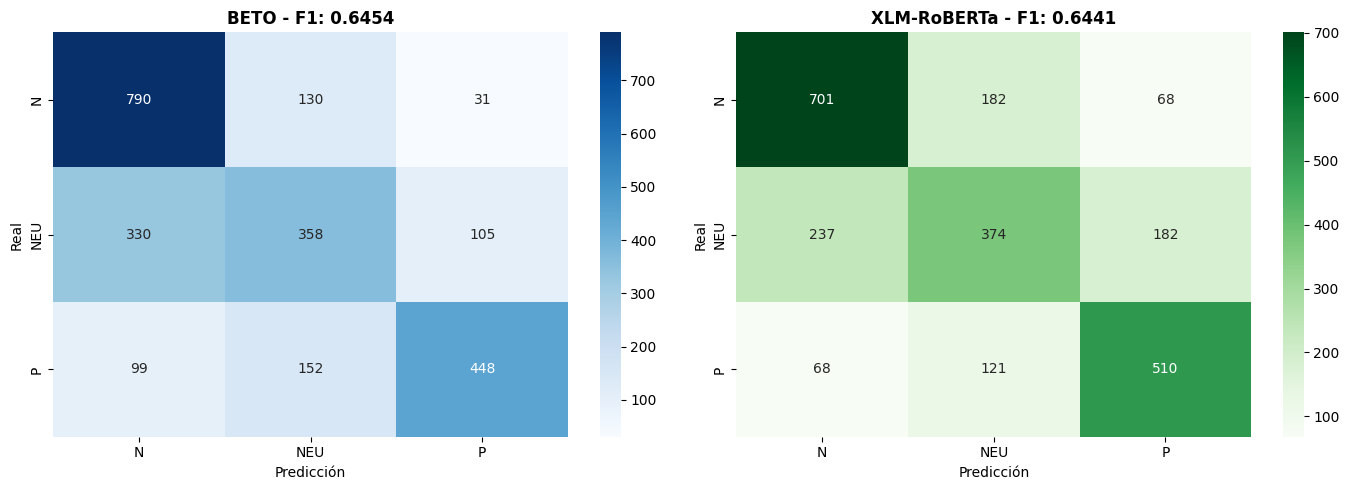


💾 Gráfico guardado: confusion_matrices_tass.png


In [13]:
# Crear matrices de confusión para ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BETO
cm_beto = confusion_matrix(results_beto['true_labels'], results_beto['predictions'])
sns.heatmap(cm_beto, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=label_list, yticklabels=label_list)
axes[0].set_title(f'BETO - F1: {results_beto["test_f1"]:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=10)
axes[0].set_ylabel('Real', fontsize=10)

# XLM-RoBERTa
cm_xlmr = confusion_matrix(results_xlmr['true_labels'], results_xlmr['predictions'])
sns.heatmap(cm_xlmr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=label_list, yticklabels=label_list)
axes[1].set_title(f'XLM-RoBERTa - F1: {results_xlmr["test_f1"]:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=10)
axes[1].set_ylabel('Real', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrices_tass.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💾 Gráfico guardado: confusion_matrices_tass.png")

## 12. Reporte de Clasificación Detallado

In [14]:
# Reportes detallados por clase
print("\n" + "="*80)
print("📊 REPORTE DETALLADO POR CLASE")
print("="*80)

print("\n🔷 BETO:")
print("-"*80)
print(classification_report(
    results_beto['true_labels'],
    results_beto['predictions'],
    target_names=label_list,
    digits=4
))

print("\n🔷 XLM-RoBERTa:")
print("-"*80)
print(classification_report(
    results_xlmr['true_labels'],
    results_xlmr['predictions'],
    target_names=label_list,
    digits=4
))

print("="*80)


📊 REPORTE DETALLADO POR CLASE

🔷 BETO:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           N     0.6481    0.8307    0.7281       951
         NEU     0.5594    0.4515    0.4997       793
           P     0.7671    0.6409    0.6984       699

    accuracy                         0.6533      2443
   macro avg     0.6582    0.6410    0.6420      2443
weighted avg     0.6533    0.6533    0.6454      2443


🔷 XLM-RoBERTa:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           N     0.6968    0.7371    0.7164       951
         NEU     0.5524    0.4716    0.5088       793
           P     0.6711    0.7296    0.6991       699

    accuracy                         0.6488      2443
   macro avg     0.6401    0.6461    0.6415      2443
weighted avg     0.6426    0.6488    0.6441      2443



## 13. Guardar Resultados

Guardar métricas y comparaciones en CSV para análisis posterior.

In [15]:
# Guardar comparación
comparison_df.to_csv('tass_results_comparison.csv', index=False)
print("✅ Resultados guardados en: tass_results_comparison.csv")

# Guardar métricas detalladas
detailed_results = {
    'beto': results_beto,
    'xlmr': results_xlmr
}

import json
with open('tass_detailed_results.json', 'w') as f:
    # Convertir arrays numpy a listas para serialización JSON
    detailed_json = {
        'beto': {k: v.tolist() if isinstance(v, np.ndarray) else v 
                  for k, v in results_beto.items()},
        'xlmr': {k: v.tolist() if isinstance(v, np.ndarray) else v 
                 for k, v in results_xlmr.items()}
    }
    json.dump(detailed_json, f, indent=2)

print("✅ Resultados detallados guardados en: tass_detailed_results.json")

✅ Resultados guardados en: tass_results_comparison.csv
✅ Resultados detallados guardados en: tass_detailed_results.json


## 14. Publicar en HuggingFace Hub

⚠️ **Los modelos ya fueron publicados automáticamente** durante el entrenamiento si `save_to_hub=True`.

Puedes verificar en:
- `https://huggingface.co/{username}/beto-tass-sentiment`
- `https://huggingface.co/{username}/xlmr-tass-sentiment`

Si necesitas republicar manualmente:

In [16]:
# Verificar modelos publicados
print("🔍 Verificando modelos en HuggingFace Hub...")
print("="*70)

try:
    from huggingface_hub import list_models
    
    user_models = list(list_models(author=username))
    tass_models = [m for m in user_models if 'tass' in m.modelId.lower()]
    
    if tass_models:
        print(f"\n✅ Modelos TASS encontrados:")
        for model in tass_models:
            print(f"   🌐 https://huggingface.co/{model.modelId}")
    else:
        print(f"\n⚠️ No se encontraron modelos TASS para el usuario {username}")
        print(f"   Verifica manualmente en: https://huggingface.co/{username}")
        
except Exception as e:
    print(f"\n⚠️ Error al verificar: {e}")
    print(f"   Verifica manualmente en: https://huggingface.co/{username}")

print("="*70)

🔍 Verificando modelos en HuggingFace Hub...

✅ Modelos TASS encontrados:
   🌐 https://huggingface.co/Lucyan85/xlnet-tass-sentiment
   🌐 https://huggingface.co/Lucyan85/beto-tass-sentiment
   🌐 https://huggingface.co/Lucyan85/xlmr-tass-sentiment
